In [1]:
from datetime import datetime
import cartopy.crs as ccrs
from py_eddy_tracker.observations.observation import EddiesObservations
import xarray as xr
from glob import glob

import cartopy
import matplotlib.pyplot as plt
import pandas as pd

# Params.

In [2]:
lon_min_ax, lon_max_ax = -6., 9.
lat_min_ax, lat_max_ax = 35., 45.

# Functions

In [3]:
def update_axes(ax, mappable=None):
    ax.grid()
    if mappable:
        plt.colorbar(mappable, cax=ax.figure.add_axes([0.94, 0.15, 0.01, 0.6]), extend='max') # original: [0.94, 0.05, 0.01, 0.9] # --> doesnt wotk:, shrink=.5)

In [4]:
def start_axes_map_subplots(title, nax): 
    """
    title = "xx ()"
    nax, e.g. 121
    """
    ax = plt.subplot(nax, projection=ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.LAND, facecolor=cartopy.feature.COLORS['land'], zorder=2) 

    ax.set_xlim(lon_min_ax, lon_max_ax), ax.set_ylim(lat_min_ax, lat_max_ax)
    ax.set_aspect("equal")
    ax.set_title(title, weight="bold")

    # Add coastlines and grid lines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True);     
    gl.top_labels = False; gl.right_labels = False

    return ax

# Loading data:

In [5]:
from pathlib import Path as PathL

# Get the user's home directory
homedir = PathL.home()
# print(f"Home directory: {homedir}")


In [6]:
indir_eddies = "data/eddy-tracker_outputs/"

## MIOST data

In [7]:
indir_miost = str(homedir) + "/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/"
indir_miost_s = indir_miost + 'subset/'

In [8]:
data_paths_MIOST_all = sorted(glob(indir_miost_s + "dt_global_allsat_phy_l4_" + "202[3-4]" + "*_sub.nc"))

In [9]:
data_paths_MIOST = data_paths_MIOST_all[0:-153] # to select only till 30/06/2024

In [10]:
ds_miost = xr.open_dataset(data_paths_MIOST[10])
ds_miost

<xarray.Dataset>
Dimensions:           (time: 1, latitude: 88, longitude: 120, bounds: 2)
Coordinates:
  * longitude         (longitude) float32 -5.938 -5.812 -5.688 ... 8.812 8.938
  * latitude          (latitude) float32 34.06 34.19 34.31 ... 44.69 44.81 44.94
  * time              (time) datetime64[ns] 2023-08-11
    longitude_bounds  (longitude, bounds) float64 ...
    latitude_bounds   (latitude, bounds) float64 ...
Dimensions without coordinates: bounds
Data variables:
    sla               (time, latitude, longitude) float64 ...
    ugosa             (time, latitude, longitude) float64 ...
    vgosa             (time, latitude, longitude) float64 ...
    adt               (time, latitude, longitude) float64 ...
    ugos              (time, latitude, longitude) float64 ...
    vgos              (time, latitude, longitude) float64 ...
Attributes: (12/46)
    description:                      Miost analysis 
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_resolution:        P1D
    title:                           DT merged all satellites Global Ocean Gr...
    time_coverage_start:             2023-08-01T12:00:00Z
    time_coverage_end:               2023-08-01T12:00:00Z
    doi:                             10.24400/527896/a01-2025.001

In [11]:
ds_miost.time.values[0]

numpy.datetime64('2023-08-11T00:00:00.000000000')

In [12]:
pd.Timestamp(ds_miost.time.values[0]).strftime('%Y%m%d')


'20230811'

### Load eddy data:

We use the date of the original MIOST data to load the eddy files.

In [13]:
data_path = data_paths_MIOST[0]
ds_miost = xr.open_dataset(data_path)

# date for eddy id:
date = pd.Timestamp(ds_miost.time.values[0]).strftime('%Y%m%d')

a_name = indir_eddies + 'a_MIOST_v2.0.1_' + date + '.nc'
c_name = indir_eddies + 'c_MIOST_v2.0.1_' + date + '.nc'

all_a_m = EddiesObservations.load_file(a_name)
all_c_m = EddiesObservations.load_file(c_name)


In [14]:
for data_path in data_paths_MIOST[1::]:
    ds_miost = xr.open_dataset(data_path)

    # date for eddy id:
    date = pd.Timestamp(ds_miost.time.values[0]).strftime('%Y%m%d')

    a_name = indir_eddies + 'a_MIOST_v2.0.1_' + date + '.nc'
    c_name = indir_eddies + 'c_MIOST_v2.0.1_' + date + '.nc'
    
    a = EddiesObservations.load_file(a_name)
    c = EddiesObservations.load_file(c_name)

    all_a_m = all_a_m.merge(a)
    all_c_m = all_c_m.merge(c)

In [15]:
all_a_m.nb_days # should be 335

335.0

**From 01/08/2023 to 30/06/2024, inclusive, there are 335 days.**

## DUACS data

We use the filename indices to extract the date to load the DUACS eddy files.

In [16]:
indir_duacs_nrt = str(homedir) + "/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/"

data_paths_DUACS_NRT_all = sorted(glob(indir_duacs_nrt + "wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_" + "202[3-4]" + "*_sub.nc"))


In [17]:
data_paths_DUACS_NRT = data_paths_DUACS_NRT_all[0:-148]

In [18]:
a_names_DUACS_NRT = []
c_names_DUACS_NRT = []

for data_path_DUACS_NRT in data_paths_DUACS_NRT:
   date = datetime(int(data_path_DUACS_NRT[-15:-11]), int(data_path_DUACS_NRT[-11:-9]),
                int(data_path_DUACS_NRT[-9:-7]))
   # print(date)
   
   a_name_DUACS_NRT = indir_eddies + 'a_DUACS-NRT_' + date.strftime('%Y%m%d') + '.nc'
   c_name_DUACS_NRT = indir_eddies + 'c_DUACS-NRT_' + date.strftime('%Y%m%d') + '.nc'
   
   a_names_DUACS_NRT.append(a_name_DUACS_NRT)
   c_names_DUACS_NRT.append(c_name_DUACS_NRT)

### remove error days DUACS-OI:

In [19]:
a_err_231109 = indir_eddies + "a_DUACS-NRT_20231109.nc"
a_err_231111 = indir_eddies + "a_DUACS-NRT_20231111.nc"

c_err_231109 = indir_eddies + "c_DUACS-NRT_20231109.nc"
c_err_231111 = indir_eddies + "c_DUACS-NRT_20231111.nc"

In [20]:
# Remove the unwanted files from the list
a_names_DUACS_NRT = [
    f for f in a_names_DUACS_NRT
    if f not in [a_err_231109, a_err_231111]
]

In [21]:
# Remove the unwanted files from the list
c_names_DUACS_NRT = [
    f for f in c_names_DUACS_NRT
    if f not in [c_err_231109, c_err_231111]
]

### Load eddy data:

In [22]:
all_a_DUACS_NRT = EddiesObservations.concatenate(
    [EddiesObservations.load_file(ff) for ff in a_names_DUACS_NRT]
)

In [23]:
all_c_DUACS_NRT = EddiesObservations.concatenate(
    [EddiesObservations.load_file(ff) for ff in c_names_DUACS_NRT]
)

# Plots:

With Map; and using center=True:

instead of inter=True, that is wrt to contours, using center=True that is wrt to eddy center:

# Merging eddies:

In [24]:
all_e_m = all_c_m.merge(all_a_m)
all_e_d = all_c_DUACS_NRT.merge(all_a_DUACS_NRT)

In [25]:
all_e_m.shape

(13206,)

In [26]:
(all_e_d.shape)

(9701,)

In [27]:
# Count pixel encompassed in each contour
step = 1 # degrees
g_e_m = all_e_m.grid_count(bins=((-10, 37, step), (30, 46, step)), center=True)
g_e_d = all_e_d.grid_count(bins=((-10, 37, step), (30, 46, step)), center=True)


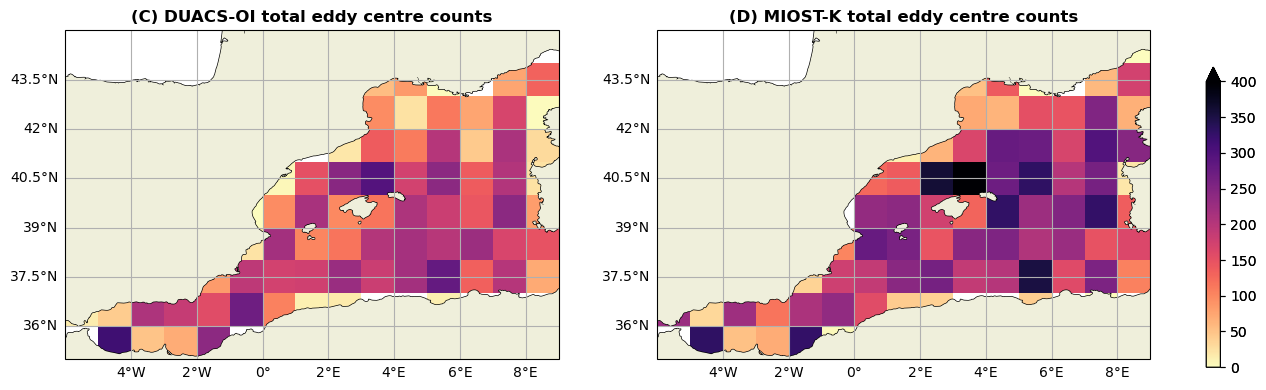

In [28]:
plt.figure(figsize=(14,5))
ax = start_axes_map_subplots("(C) DUACS-OI total eddy centre counts", 121) 
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

m = g_e_d.display(
    ax, cmap="magma_r", name="count", vmin=0, vmax=400, transform=ccrs.PlateCarree() 
)

update_axes(ax, m)

ax = start_axes_map_subplots("(D) MIOST-K total eddy centre counts", 122) 
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

m = g_e_m.display(
    ax, cmap="magma_r", name="count", vmin=0, vmax=400, transform=ccrs.PlateCarree() 
)

update_axes(ax, m)

plt.savefig("figures/fig2c-d.png", dpi=300, bbox_inches="tight")


Code references

https://py-eddy-tracker.readthedocs.io/en/stable/python_module/02_eddy_identification/pet_eddy_detection.html

https://py-eddy-tracker.readthedocs.io/en/stable/python_module/02_eddy_identification/pet_statistics_on_identification.html#sphx-glr-python-module-02-eddy-identification-pet-statistics-on-identification-py